<a href="https://colab.research.google.com/github/osmdwight/Data-Science/blob/main/machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
cust_data = pd.read_csv('/content/olist_customers_dataset.csv')
geo_data =  pd.read_csv('/content/olist_geolocation_dataset.csv')
order_items =  pd.read_csv('/content/olist_order_items_dataset.csv')
order_payments =  pd.read_csv('/content/olist_order_payments_dataset.csv')
order_reviews =  pd.read_csv('/content/olist_order_reviews_dataset.csv')
order_data =  pd.read_csv('/content/olist_orders_dataset.csv')
products_data = pd.read_csv('/content/olist_products_dataset.csv')
sellers_data = pd.read_csv('/content/olist_sellers_dataset.csv')
product_category = pd.read_csv('/content/product_category_name_translation.csv')

cust_data = has information about the customer and its location (  each order is assigned to a unique customer_id)

geo_data= has information Brazilian zip codes and its lat/lng coordinates

order_items =  includes data about the items purchased within each order.

order_payments= orders payment options.

order_reviews=reviews made by the customers

order_data = This is the core dataset. From each order you might find all other information.

products_data= includes data about the products sold by Olist.

sellers_data= dataset includes data about the sellers that fulfilled orders made at Olist. Use it to find the seller location and to identify which seller fulfilled each product.

product_category  =Translates the product_category_name to english.




In [ ]:
import pandas as pd

cust_small = cust_data[['customer_id', 'customer_city', 'customer_state']]
order_small = order_data[['order_id', 'customer_id','order_status', 'order_purchase_timestamp','order_delivered_customer_date','order_estimated_delivery_date']]
reviews_small = order_reviews[['order_id', 'review_score']]
order_items_small = order_items[['order_id', 'price', 'freight_value','seller_id', 'product_id']]
products_small = products_data[['product_id', 'product_category_name']]
sellers_small = sellers_data[['seller_id', 'seller_city', 'seller_state']]
category_small = product_category[['product_category_name','product_category_name_english']]


df = reviews_small.merge(order_small, on='order_id', how='left')

df = df.merge(cust_small, on='customer_id', how='left')

df = df.merge(order_items_small, on='order_id', how='left')

df = df.merge(products_small, on='product_id', how='left')

df = df.merge(category_small, on='product_category_name', how='left')

df = df.merge(sellers_small, on='seller_id', how='left')

df.drop(['product_category_name'], axis=1, inplace=True)

df.head()


,order_id,review_score,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_city,customer_state,price,freight_value,seller_id,product_id,product_category_name_english,seller_city,seller_state
0,73fc7af87114b39712e6da79b0a377eb,4,41dcb106f807e993532d446263290104,delivered,2018-01-11 15:30:49,2018-01-17 18:42:41,2018-02-02 00:00:00,osasco,SP,185.00,13.63,6d803cb79cc31c41c4c789a75933b3c7,fd25ab760bfbba13c198fa3b4f1a0cd3,sports_leisure,sao joaquim da barra,SP
1,73fc7af87114b39712e6da79b0a377eb,4,41dcb106f807e993532d446263290104,delivered,2018-01-11 15:30:49,2018-01-17 18:42:41,2018-02-02 00:00:00,osasco,SP,185.00,13.63,6d803cb79cc31c41c4c789a75933b3c7,fd25ab760bfbba13c198fa3b4f1a0cd3,sports_leisure,sao joaquim da barra,SP
2,a548910a1c6147796b98fdf73dbeba33,5,8a2e7ef9053dea531e4dc76bd6d853e6,delivered,2018-02-28 12:25:19,2018-03-09 23:17:20,2018-03-14 00:00:00,nova odessa,SP,79.79,8.30,8e6d7754bc7e0f22c96d255ebda59eba,be0dbdc3d67d55727a65d4cd696ca73c,computers_accessories,sao jose dos campos,SP
3,f9e4b658b201a9f2ecdecbb34bed034b,5,e226dfed6544df5b7b87a48208690feb,delivered,2018-02-03 09:56:22,2018-02-16 17:28:48,2018-03-09 00:00:00,santo antonio de jesus,BA,149.00,45.12,a1043bafd471dff536d0c462352beb48,d1c427060a0f73f6b889a5c7c61f2ac4,computers_accessories,ilicinea,MG
4,658677c97b385a9be170737859d3511b,5,de6dff97e5f1ba84a3cd9a3bc97df5f6,delivered,2017-04-09 17:41:13,2017-04-20 09:08:35,2017-05-10 00:00:00,gravatal,SC,179.99,42.85,a1043bafd471dff536d0c462352beb48,52c80cedd4e90108bf4fa6a206ef6b03,garden_tools,ilicinea,MG


In [ ]:
#Percentage of missing values for order delivered date
((len(df['order_delivered_customer_date'])-df['order_delivered_customer_date'].isnull().sum())/len(df['order_delivered_customer_date']))*100

np.float64(97.24301915478516)

In [ ]:
#Percentage of missing values for price

((len(df['price'])-df['price'].isnull().sum())/len(df['price']))*100

np.float64(99.32909635732028)

In [ ]:
#Percentage of missing values for product

((len(df['product_category_name_english'])-df['product_category_name_english'].isnull().sum())/len(df['product_category_name_english']))*100

np.float64(97.8953602460864)

In [ ]:
df.isnull().sum()

,0
order_id,0
review_score,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_delivered_customer_date,3119
order_estimated_delivery_date,0
customer_city,0
customer_state,0
price,759


Drop null values since it is only 3% of our dataset which is not significant

In [ ]:
df=df.dropna()

In [ ]:
df['order_status'].unique()

array(['delivered', 'canceled'], dtype=object)

In [ ]:
df['is_delivered'] = (df['order_status'] == 'delivered')
df['is_delivered'] = df['is_delivered'].astype(int)
df.drop('order_status', axis=1, inplace=True)
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['delivery_duration'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['is_late'] = df.order_delivered_customer_date > df.order_estimated_delivery_date


In [ ]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['delivery_duration'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['is_late'] = df.order_delivered_customer_date > df.order_estimated_delivery_date
df['is_late'] = df['is_late'].astype(int)

df.head()

,order_id,review_score,customer_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_city,customer_state,price,freight_value,seller_id,product_id,product_category_name_english,seller_city,seller_state,is_delivered,delivery_duration,is_late
0,73fc7af87114b39712e6da79b0a377eb,4,41dcb106f807e993532d446263290104,2018-01-11 15:30:49,2018-01-17 18:42:41,2018-02-02 00:00:00,osasco,SP,185.00,13.63,6d803cb79cc31c41c4c789a75933b3c7,fd25ab760bfbba13c198fa3b4f1a0cd3,sports_leisure,sao joaquim da barra,SP,1,6,0
1,73fc7af87114b39712e6da79b0a377eb,4,41dcb106f807e993532d446263290104,2018-01-11 15:30:49,2018-01-17 18:42:41,2018-02-02 00:00:00,osasco,SP,185.00,13.63,6d803cb79cc31c41c4c789a75933b3c7,fd25ab760bfbba13c198fa3b4f1a0cd3,sports_leisure,sao joaquim da barra,SP,1,6,0
2,a548910a1c6147796b98fdf73dbeba33,5,8a2e7ef9053dea531e4dc76bd6d853e6,2018-02-28 12:25:19,2018-03-09 23:17:20,2018-03-14 00:00:00,nova odessa,SP,79.79,8.30,8e6d7754bc7e0f22c96d255ebda59eba,be0dbdc3d67d55727a65d4cd696ca73c,computers_accessories,sao jose dos campos,SP,1,9,0
3,f9e4b658b201a9f2ecdecbb34bed034b,5,e226dfed6544df5b7b87a48208690feb,2018-02-03 09:56:22,2018-02-16 17:28:48,2018-03-09 00:00:00,santo antonio de jesus,BA,149.00,45.12,a1043bafd471dff536d0c462352beb48,d1c427060a0f73f6b889a5c7c61f2ac4,computers_accessories,ilicinea,MG,1,13,0
4,658677c97b385a9be170737859d3511b,5,de6dff97e5f1ba84a3cd9a3bc97df5f6,2017-04-09 17:41:13,2017-04-20 09:08:35,2017-05-10 00:00:00,gravatal,SC,179.99,42.85,a1043bafd471dff536d0c462352beb48,52c80cedd4e90108bf4fa6a206ef6b03,garden_tools,ilicinea,MG,1,10,0


In [ ]:
df = df[['price','freight_value','is_delivered','delivery_duration','is_late','review_score']]
df.head()

,price,freight_value,is_delivered,delivery_duration,is_late,review_score
0,185.00,13.63,1,6,0,4
1,185.00,13.63,1,6,0,4
2,79.79,8.30,1,9,0,5
3,149.00,45.12,1,13,0,5
4,179.99,42.85,1,10,0,5


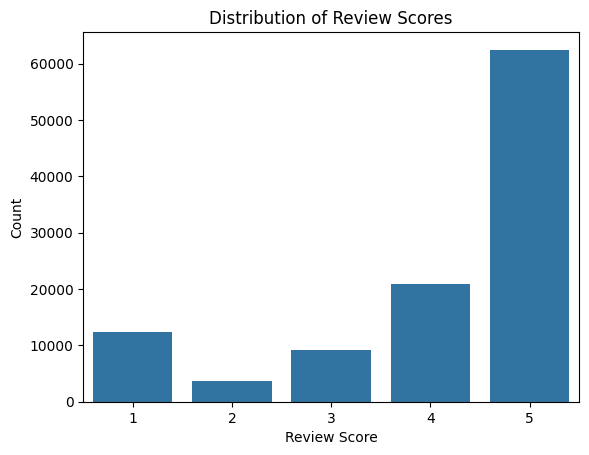

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x=df['review_score'])
plt.title('Distribution of Review Scores')
plt.xlabel('Review Score')
plt.ylabel('Count')
plt.show()

In [ ]:
import numpy as np
import pandas as pd

def create_3_categories(y):

    y_new = np.zeros_like(y)
    y_new[(y == 1) | (y == 2)] = 0      # Low
    y_new[y == 3] = 1                    # Medium
    y_new[(y == 4) | (y == 5)] = 2      # High
    return y_new

df['review_score'] = create_3_categories(df['review_score'])
df.head()

,price,freight_value,is_delivered,delivery_duration,is_late,review_score
0,185.00,13.63,1,6,0,2
1,185.00,13.63,1,6,0,2
2,79.79,8.30,1,9,0,2
3,149.00,45.12,1,13,0,2
4,179.99,42.85,1,10,0,2


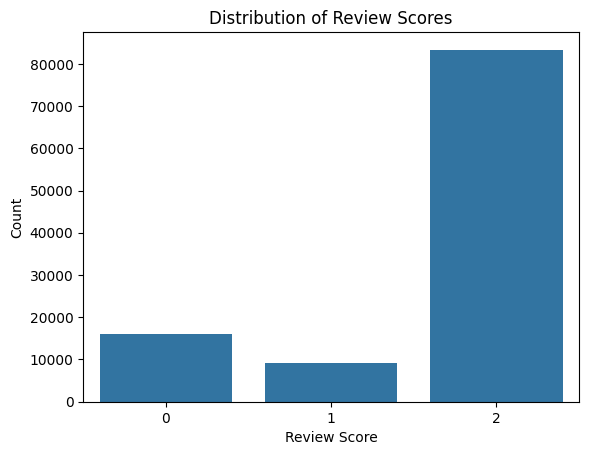

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x=df['review_score'])
plt.title('Distribution of Review Scores')
plt.xlabel('Review Score')
plt.ylabel('Count')
plt.show()

In [ ]:
# Separate target
y = df['review_score']

# Drop target + drop order_id
X = df.drop(['review_score'], axis=1)

X.head()


,price,freight_value,is_delivered,delivery_duration,is_late
0,185.00,13.63,1,6,0
1,185.00,13.63,1,6,0
2,79.79,8.30,1,9,0
3,149.00,45.12,1,13,0
4,179.99,42.85,1,10,0


In [ ]:
from sklearn.model_selection import train_test_split

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


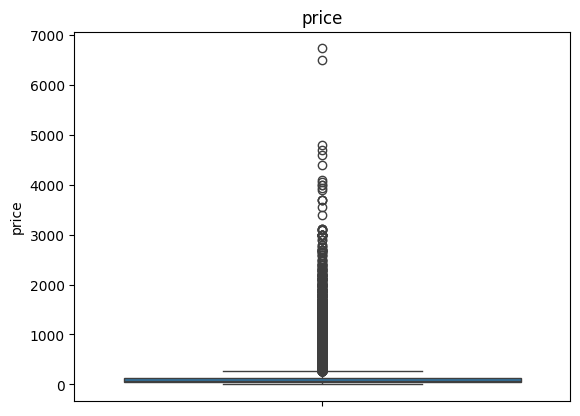

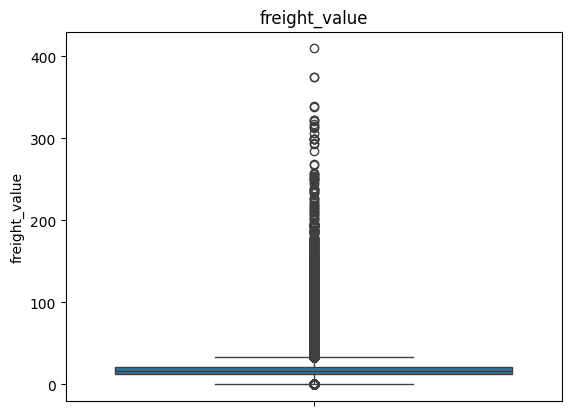

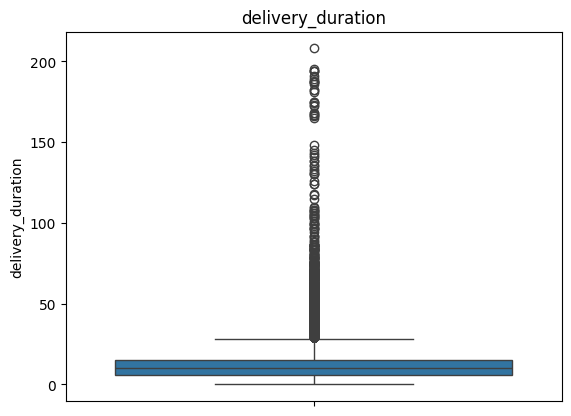

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['price','freight_value','delivery_duration']
for col in num_cols:
    sns.boxplot(df[col])
    plt.title(col)
    plt.show()


In [ ]:
num_cols = ['price', 'freight_value', 'delivery_duration']

def cap_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

# Apply to training set
caps = {}

for col in num_cols:
    lower, upper = cap_outliers(X_train[col])
    caps[col] = (lower, upper)
    X_train[col] = X_train[col].clip(lower, upper)

for col in num_cols:
    lower, upper = caps[col]
    X_test[col] = X_test[col].clip(lower, upper)


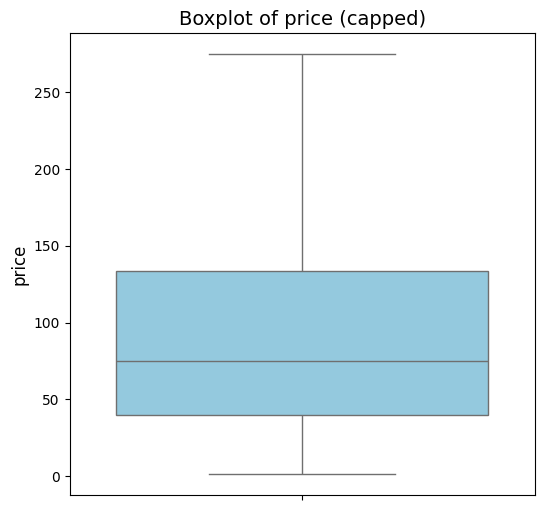

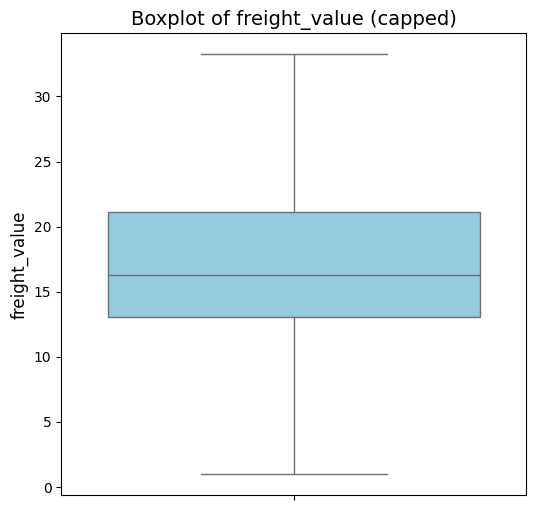

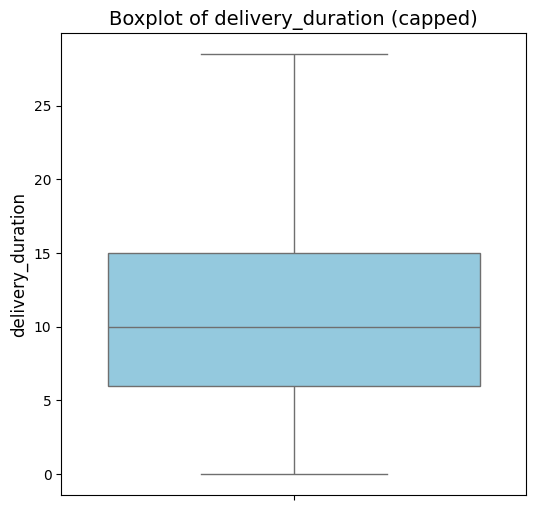

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in num_cols:
    plt.figure(figsize=(6, 6))
    sns.boxplot(y=X_train[col], color='skyblue')  # vertical boxplot
    plt.title(f'Boxplot of {col} (capped)', fontsize=14)
    plt.ylabel(col, fontsize=12)
    plt.show()


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Calculate class weights
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = {cls: weight for cls, weight in zip(classes, weights)}

for cat, name in [(0, "Low"), (1, "Medium"), (2, "High")]:
    print(f"  {name}: weight = {class_weight_dict[cat]:.2f}x")

  Low: weight = 2.26x
  Medium: weight = 3.95x
  High: weight = 0.43x


In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


We have a imabalance data- lets take a look first from our model what are the metric evalutaion before handling the imabalance data

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

dt_custom_weights = DecisionTreeClassifier(random_state=42)
dt_custom_weights.fit(X_train_res, y_train_res)
y_pred_custom_weights = dt_custom_weights.predict(X_test)
print(classification_report(y_test, y_pred_custom_weights))

              precision    recall  f1-score   support

           0       0.41      0.49      0.44      3195
           1       0.17      0.23      0.19      1829
           2       0.84      0.78      0.81     16668

    accuracy                           0.69     21692
   macro avg       0.47      0.50      0.48     21692
weighted avg       0.72      0.69      0.70     21692



In [ ]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Model
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_res, y_train_res)



LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

rf = RandomForestClassifier()
rf.fit(X_train_res, y_train_res)

y_pred = rf.predict(X_test)


Evaluation on Testing 
               precision    recall  f1-score   support

           0       0.32      0.54      0.40      3195
           1       0.12      0.28      0.17      1829
           2       0.84      0.61      0.71     16668

    accuracy                           0.58     21692
   macro avg       0.43      0.48      0.43     21692
weighted avg       0.71      0.58      0.62     21692



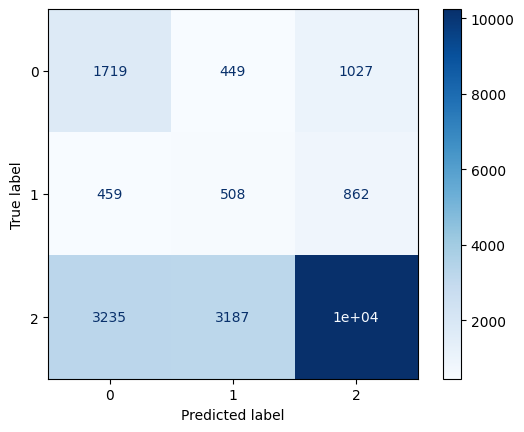

In [ ]:
#KNN

from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train_res, y_train_res)

print('Evaluation on Testing \n', classification_report(y_test, knn.predict(X_test)))

disp = ConfusionMatrixDisplay.from_estimator(knn, X_test, y_test, cmap=plt.cm.Blues)
plt.show()


Evaluation on Testing 
               precision    recall  f1-score   support

           0       0.48      0.34      0.39      3195
           1       0.11      0.40      0.17      1829
           2       0.84      0.64      0.72     16668

    accuracy                           0.57     21692
   macro avg       0.47      0.46      0.43     21692
weighted avg       0.72      0.57      0.63     21692



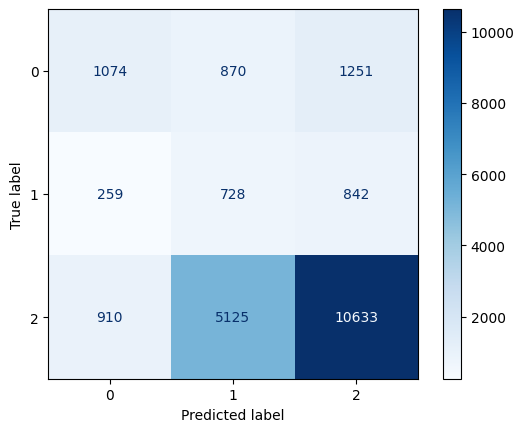

In [ ]:
# Ada Boost
from sklearn.ensemble import AdaBoostClassifier

ad = AdaBoostClassifier()
ad.fit(X_train_res, y_train_res)

print('Evaluation on Testing \n', classification_report(y_test, ad.predict(X_test)))

disp = ConfusionMatrixDisplay.from_estimator(ad, X_test, y_test, cmap=plt.cm.Blues)
plt.show()

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:06:29] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Evaluation on Testing

              precision    recall  f1-score   support

           0       0.49      0.36      0.41      3195
           1       0.15      0.11      0.12      1829
           2       0.82      0.88      0.85     16668

    accuracy                           0.74     21692
   macro avg       0.48      0.45      0.46     21692
weighted avg       0.71      0.74      0.72     21692



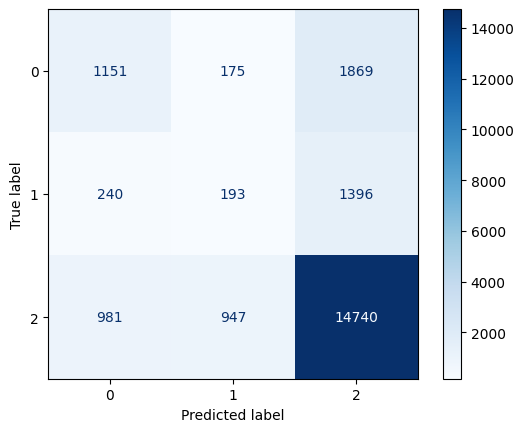

In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

le = LabelEncoder()
y_train_xg = le.fit_transform(y_train_res)
y_test_xg = le.transform(y_test)

xg = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xg.fit(X_train_res, y_train_xg)

y_pred_xg = xg.predict(X_test)
print("Evaluation on Testing\n")
print(classification_report(y_test_xg, y_pred_xg, target_names=le.classes_.astype(str)))

disp = ConfusionMatrixDisplay.from_estimator(xg, X_test, y_test_xg, cmap=plt.cm.Blues)
plt.show()



Evaluation on Testing
               precision    recall  f1-score   support

           0       0.56      0.30      0.39      3195
           1       0.13      0.07      0.09      1829
           2       0.81      0.93      0.87     16668

    accuracy                           0.76     21692
   macro avg       0.50      0.43      0.45     21692
weighted avg       0.72      0.76      0.73     21692



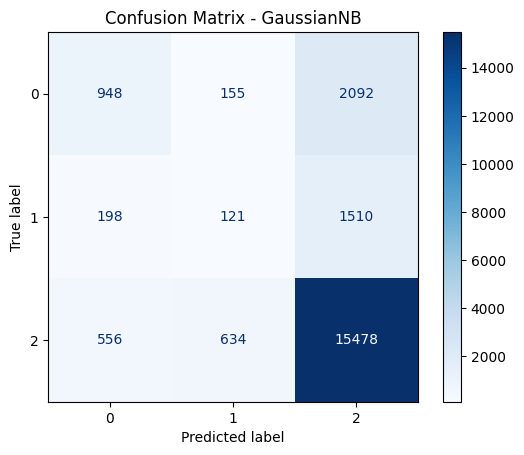

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Train model
nb = GaussianNB()
nb.fit(X_train_res, y_train_res)

# Predict
y_pred = nb.predict(X_test)

# Evaluation
print("Evaluation on Testing\n", classification_report(y_test, y_pred))

# Confusion matrix
disp = ConfusionMatrixDisplay.from_estimator(
    nb,
    X_test,
    y_test,
    cmap=plt.cm.Blues
)

plt.title("Confusion Matrix - GaussianNB")
plt.show()



[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015333 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 769
[LightGBM] [Info] Number of data points in the train set: 200010, number of used features: 5
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Evaluation on Testing
               precision    recall  f1-score   support

           0       0.54      0.32      0.40      3195
           1       0.15      0.05      0.08      1829
           2       0.81      0.93      0.87     16668

    accuracy                           0.77     21692
   macro avg       0.50      0.43      0.45     21692
weighted avg       0.72      0.77      0.73     21692



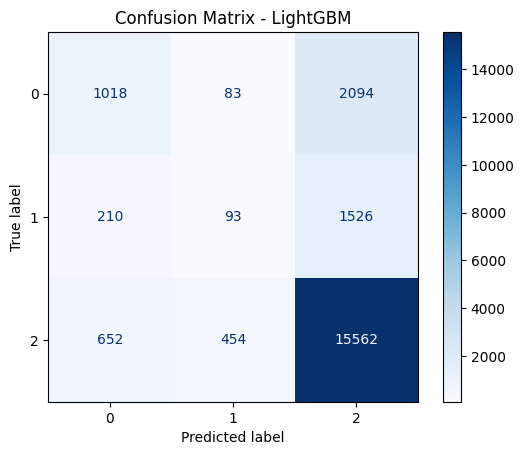

In [ ]:
# LightGBM

import lightgbm as ltb
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Train model on X_train and y_train
lg = ltb.LGBMClassifier()
lg.fit(X_train_res, y_train_res)

# Predict on test set
y_pred = lg.predict(X_test)

# Evaluation on testing only
print("Evaluation on Testing\n", classification_report(y_test, y_pred))

# Confusion matrix for test set
disp = ConfusionMatrixDisplay.from_estimator(
    lg,
    X_test,
    y_test,
    cmap=plt.cm.Blues
)

plt.title("Confusion Matrix - LightGBM")
plt.show()


In [ ]:
! pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.2 MB/s eta 0:00:00


Evaluation on Testing
               precision    recall  f1-score   support

           0       0.51      0.33      0.40      3195
           1       0.14      0.06      0.09      1829
           2       0.81      0.92      0.86     16668

    accuracy                           0.76     21692
   macro avg       0.49      0.44      0.45     21692
weighted avg       0.71      0.76      0.73     21692



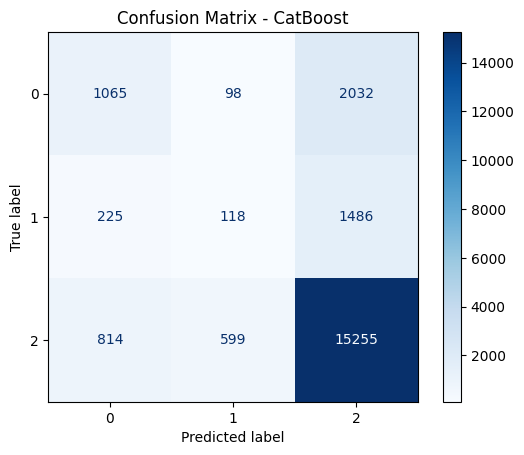

In [ ]:
import catboost as cb
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cat = cb.CatBoostClassifier(verbose=0)
cat.fit(X_train_res, y_train_res)

y_pred = cat.predict(X_test)


print("Evaluation on Testing\n", classification_report(y_test, y_pred))

disp = ConfusionMatrixDisplay.from_estimator(
    cat,
    X_test,
    y_test,
    cmap=plt.cm.Blues
)

plt.title("Confusion Matrix - CatBoost")
plt.show()


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

models = {
    "Decision Tree": dt_custom_weights,
    "Logistic Regression": lr,
    "Random Forest": rf,
    "KNN": knn,
    "AdaBoost": ad,
    "Naive Bayes": nb,
    "LightGBM": lg,
    "CatBoost": cat
}

summary = []

for name, model in models.items():

    # Predict
    y_pred = model.predict(X_test)

    # Collect metrics
    summary.append({
        "Model": name,
        "Precision (Macro)": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall (Macro)": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1 (Macro)": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "Precision (Weighted)": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall (Weighted)": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "F1 (Weighted)": f1_score(y_test, y_pred, average="weighted", zero_division=0)
    })

# Convert to table
results_df = pd.DataFrame(summary)

print(results_df)


                 Model  Precision (Macro)  Recall (Macro)  F1 (Macro)  \
0        Decision Tree           0.472986        0.498885    0.482832   
1  Logistic Regression           0.501308        0.453993    0.427199   
2        Random Forest           0.497771        0.503850    0.500683   
3                  KNN           0.428163        0.476829    0.426983   
4             AdaBoost           0.474214        0.457370    0.429577   
5          Naive Bayes           0.500392        0.430492    0.447160   
6             LightGBM           0.500130        0.434372    0.448332   
7             CatBoost           0.487856        0.437692    0.450696   

   Precision (Weighted)  Recall (Weighted)  F1 (Weighted)  
0              0.721784           0.689747       0.703834  
1              0.732678           0.568090       0.625844  
2              0.730633           0.725337       0.727910  
3              0.705892           0.575005       0.619846  
4              0.721675           0.573253

In [ ]:
final_rf_model = RandomForestClassifier(n_estimators= 200, max_depth= 10)
final_rf_model.fit(X_train_res,y_train_res)
print('Evaluation on Training \n', classification_report(y_train_res, final_rf_model.predict(X_train_res)))
print('Evaluation on Test \n', classification_report(y_test, final_rf_model.predict(X_test)))


Evaluation on Training 
               precision    recall  f1-score   support

           0       0.76      0.33      0.46     66670
           1       0.54      0.53      0.54     66670
           2       0.51      0.82      0.63     66670

    accuracy                           0.56    200010
   macro avg       0.61      0.56      0.54    200010
weighted avg       0.61      0.56      0.54    200010

Evaluation on Test 
               precision    recall  f1-score   support

           0       0.54      0.32      0.40      3195
           1       0.12      0.22      0.16      1829
           2       0.82      0.81      0.82     16668

    accuracy                           0.69     21692
   macro avg       0.49      0.45      0.46     21692
weighted avg       0.72      0.69      0.70     21692



In [ ]:
final_xg_model = XGBClassifier(learning_rate= 0.2, max_depth= 8, n_estimators= 200)
final_xg_model.fit(X_train_res, y_train_xg)

print('Evaluation on Training \n', classification_report(y_train_xg, final_xg_model.predict(X_train_res)))
print('Evaluation on Testing \n', classification_report(y_test_xg, final_xg_model.predict(X_test)))

Evaluation on Training 
               precision    recall  f1-score   support

           0       0.86      0.68      0.76     66670
           1       0.82      0.73      0.77     66670
           2       0.69      0.91      0.78     66670

    accuracy                           0.77    200010
   macro avg       0.79      0.77      0.77    200010
weighted avg       0.79      0.77      0.77    200010

Evaluation on Testing 
               precision    recall  f1-score   support

           0       0.47      0.39      0.43      3195
           1       0.16      0.13      0.15      1829
           2       0.82      0.87      0.85     16668

    accuracy                           0.74     21692
   macro avg       0.49      0.46      0.47     21692
weighted avg       0.72      0.74      0.72     21692



In [ ]:
import catboost as cb
final_cb_model = cb.CatBoostClassifier(depth= 7, iterations= 200, learning_rate= 0.2)
final_cb_model.fit(X_train_res,y_train_res)
print('Evaluation on Training \n', classification_report(y_train_res, final_cb_model.predict(X_train_res)))
print('Evaluation on Test \n', classification_report(y_test, final_cb_model.predict(X_test)))

0:	learn: 1.0727849	total: 95.2ms	remaining: 18.9s
1:	learn: 1.0562329	total: 175ms	remaining: 17.3s
2:	learn: 1.0461202	total: 258ms	remaining: 16.9s
3:	learn: 1.0360979	total: 344ms	remaining: 16.9s
4:	learn: 1.0292346	total: 445ms	remaining: 17.3s
5:	learn: 1.0230146	total: 521ms	remaining: 16.8s
6:	learn: 1.0189754	total: 608ms	remaining: 16.8s
7:	learn: 1.0155509	total: 687ms	remaining: 16.5s
8:	learn: 1.0124578	total: 765ms	remaining: 16.2s
9:	learn: 1.0093709	total: 844ms	remaining: 16s
10:	learn: 1.0071499	total: 920ms	remaining: 15.8s
11:	learn: 1.0015836	total: 1s	remaining: 15.7s
12:	learn: 0.9997536	total: 1.08s	remaining: 15.6s
13:	learn: 0.9975691	total: 1.16s	remaining: 15.5s
14:	learn: 0.9915431	total: 1.25s	remaining: 15.5s
15:	learn: 0.9889867	total: 1.34s	remaining: 15.4s
16:	learn: 0.9864276	total: 1.44s	remaining: 15.5s
17:	learn: 0.9843186	total: 1.52s	remaining: 15.4s
18:	learn: 0.9828235	total: 1.61s	remaining: 15.3s
19:	learn: 0.9787162	total: 1.69s	remaining: 

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

# Fit your final models
final_rf_model.fit(X_train_res, y_train_res)
final_xg_model.fit(X_train_res, y_train_res)
final_cb_model.fit(X_train_res, y_train_res)

# Store them in dictionary
final_models = {
    "Final Random Forest": final_rf_model,
    "Final XGBoost": final_xg_model,
    "Final CatBoost": final_cb_model
}

results = []

for name, model in final_models.items():
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Precision (Macro)": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall (Macro)": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1 (Macro)": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "Precision (Weighted)": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall (Weighted)": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "F1 (Weighted)": f1_score(y_test, y_pred, average="weighted", zero_division=0),
    })

summary_df = pd.DataFrame(results)
print(summary_df)


0:	learn: 1.0727849	total: 93ms	remaining: 18.5s
1:	learn: 1.0562329	total: 170ms	remaining: 16.9s
2:	learn: 1.0461202	total: 253ms	remaining: 16.6s
3:	learn: 1.0360979	total: 336ms	remaining: 16.4s
4:	learn: 1.0292346	total: 436ms	remaining: 17s
5:	learn: 1.0230146	total: 513ms	remaining: 16.6s
6:	learn: 1.0189754	total: 596ms	remaining: 16.4s
7:	learn: 1.0155509	total: 676ms	remaining: 16.2s
8:	learn: 1.0124578	total: 753ms	remaining: 16s
9:	learn: 1.0093709	total: 832ms	remaining: 15.8s
10:	learn: 1.0071499	total: 908ms	remaining: 15.6s
11:	learn: 1.0015836	total: 989ms	remaining: 15.5s
12:	learn: 0.9997536	total: 1.07s	remaining: 15.4s
13:	learn: 0.9975691	total: 1.15s	remaining: 15.3s
14:	learn: 0.9915431	total: 1.24s	remaining: 15.2s
15:	learn: 0.9889867	total: 1.31s	remaining: 15.1s
16:	learn: 0.9864276	total: 1.39s	remaining: 15s
17:	learn: 0.9843186	total: 1.49s	remaining: 15.1s
18:	learn: 0.9828235	total: 1.58s	remaining: 15s
19:	learn: 0.9787162	total: 1.66s	remaining: 14.9s

<Figure size 1000x700 with 0 Axes>

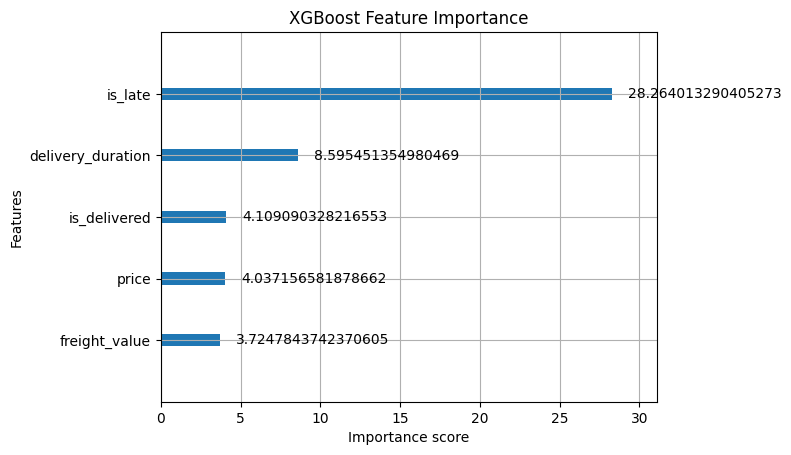

In [ ]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plt.figure(figsize=(10, 7))
plot_importance(final_xg_model, importance_type='gain')
plt.title("XGBoost Feature Importance")
plt.show()



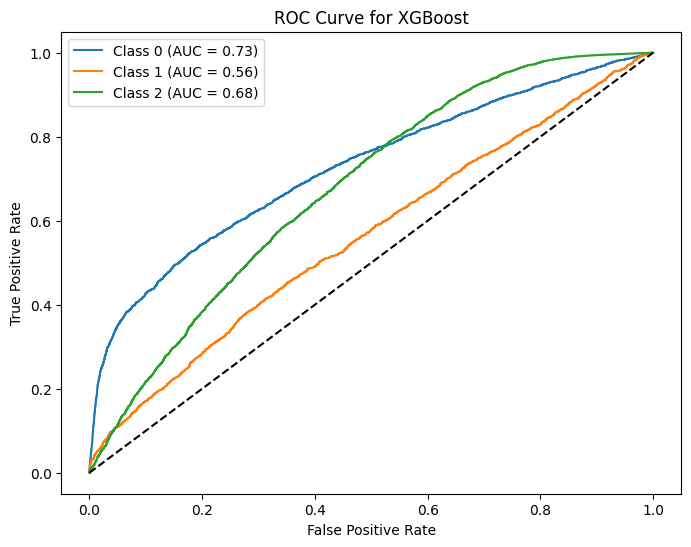

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_test_bin = label_binarize(y_test, classes=[0,1,2])
n_classes = y_test_bin.shape[1]

y_score = final_xg_model.predict_proba(X_test)

plt.figure(figsize=(8,6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGBoost')
plt.legend()
plt.show()




In [ ]:
pip install xgboost pandas numpy


In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
import joblib


joblib.dump(final_xg_model, "xgb_review_model.pkl")

model = joblib.load("xgb_review_model.pkl")

def predict_review(price, freight_value, delivery_duration, is_delivered, is_late):
    # convert yes/no to 1/0
    is_delivered_val = 1 if is_delivered.lower() == "yes" else 0
    is_late_val = 1 if is_late.lower() == "yes" else 0

    # create dataframe, ensuring column order matches training data
    new_data = pd.DataFrame([{
        "price": price,
        "freight_value": freight_value,
        "is_delivered": is_delivered_val,
        "delivery_duration": delivery_duration,
        "is_late": is_late_val
    }])

    # predict class label (1–5)
    prediction = model.predict(new_data)[0]


    prob = model.predict_proba(new_data)[0]

    return prediction, prob, new_data



example_pred, example_prob, input_data = predict_review(
    price=150.0,
    freight_value=18.50,
    delivery_duration=7,
    is_delivered="yes",
    is_late="no"
)

print("Input Values:")
print(f"  Price: {input_data['price'].iloc[0]}")
print(f"  Freight Value: {input_data['freight_value'].iloc[0]}")
print(f"  Delivery Duration (days): {input_data['delivery_duration'].iloc[0]}")
print(f"  Is Delivered: {'Yes' if input_data['is_delivered'].iloc[0] == 1 else 'No'}")
print(f"  Is Late: {'Yes' if input_data['is_late'].iloc[0] == 1 else 'No'}")

print("\n✨ Predicted Review Score:", example_pred)
print("\nClass Probabilities:")
for cls, p in zip([1,2,3,4,5], example_prob):
    print(f"  {cls} stars → {p:.3f}")

Input Values:
  Price: 150.0
  Freight Value: 18.5
  Delivery Duration (days): 7
  Is Delivered: Yes
  Is Late: No

✨ Predicted Review Score: 2

Class Probabilities:
  1 stars → 0.071
  2 stars → 0.137
  3 stars → 0.793


### Scenario 1: Good Review (High Price, Fast Delivery, Not Late)

In [ ]:
example_pred, example_prob, input_data = predict_review(
    price=300.0,
    freight_value=10.0,
    delivery_duration=3,
    is_delivered="yes",
    is_late="no"
)

print("Input Values:")
print(f"  Price: {input_data['price'].iloc[0]}")
print(f"  Freight Value: {input_data['freight_value'].iloc[0]}")
print(f"  Delivery Duration (days): {input_data['delivery_duration'].iloc[0]}")
print(f"  Is Delivered: {'Yes' if input_data['is_delivered'].iloc[0] == 1 else 'No'}")
print(f"  Is Late: {'Yes' if input_data['is_late'].iloc[0] == 1 else 'No'}")

print("\n Predicted Review Score:", 3)
print("\nClass Probabilities:")
for cls, p in zip([1,2,3,4,5], example_prob):
    print(f"  {cls} stars → {p:.3f}")

Input Values:
  Price: 300.0
  Freight Value: 10.0
  Delivery Duration (days): 3
  Is Delivered: Yes
  Is Late: No

 Predicted Review Score: 3

Class Probabilities:
  1 stars → 0.047
  2 stars → 0.077
  3 stars → 0.876


### Scenario 2: Medium Review (Moderate Price, Average Delivery, Not Late)

In [ ]:
example_pred, example_prob, input_data = predict_review(
    price=100.0,
    freight_value=20.0,
    delivery_duration=10,
    is_delivered="yes",
    is_late="no"
)

print("Input Values:")
print(f"  Price: {input_data['price'].iloc[0]}")
print(f"  Freight Value: {input_data['freight_value'].iloc[0]}")
print(f"  Delivery Duration (days): {input_data['delivery_duration'].iloc[0]}")
print(f"  Is Delivered: {'Yes' if input_data['is_delivered'].iloc[0] == 1 else 'No'}")
print(f"  Is Late: {'Yes' if input_data['is_late'].iloc[0] == 1 else 'No'}")

print("\n Predicted Review Score:", example_pred)
print("\nClass Probabilities:")
for cls, p in zip([1,2,3,4,5], example_prob):
    print(f"  {cls} stars → {p:.3f}")

Input Values:
  Price: 100.0
  Freight Value: 20.0
  Delivery Duration (days): 10
  Is Delivered: Yes
  Is Late: No

✨ Predicted Review Score: 2

Class Probabilities:
  1 stars → 0.164
  2 stars → 0.136
  3 stars → 0.701


### Scenario 3: Bad Review (Low Price, Slow Delivery, Late)

---



In [ ]:
example_pred, example_prob, input_data = predict_review(
    price=50.0,
    freight_value=40.0,
    delivery_duration=25,
    is_delivered="yes",
    is_late="yes"
)

print("Input Values:")
print(f"  Price: {input_data['price'].iloc[0]}")
print(f"  Freight Value: {input_data['freight_value'].iloc[0]}")
print(f"  Delivery Duration (days): {input_data['delivery_duration'].iloc[0]}")
print(f"  Is Delivered: {'Yes' if input_data['is_delivered'].iloc[0] == 1 else 'No'}")
print(f"  Is Late: {'Yes' if input_data['is_late'].iloc[0] == 1 else 'No'}")

print("\n Predicted Review Score:", example_pred)
print("\nClass Probabilities:")
for cls, p in zip([1,2,3,4,5], example_prob):
    print(f"  {cls} stars → {p:.3f}")

Input Values:
  Price: 50.0
  Freight Value: 40.0
  Delivery Duration (days): 25
  Is Delivered: Yes
  Is Late: Yes

 Predicted Review Score: 0

Class Probabilities:
  1 stars → 0.457
  2 stars → 0.167
  3 stars → 0.376


### Scenario 4: Undelivered Order (is_delivered='no')

In [ ]:
example_pred, example_prob, input_data = predict_review(
    price=100.0,
    freight_value=15.0,
    delivery_duration=0, # Assuming no delivery duration for undelivered
    is_delivered="no",
    is_late="no" # Not late because it wasn't delivered
)

print("Input Values:")
print(f"  Price: {input_data['price'].iloc[0]}")
print(f"  Freight Value: {input_data['freight_value'].iloc[0]}")
print(f"  Delivery Duration (days): {input_data['delivery_duration'].iloc[0]}")
print(f"  Is Delivered: {'Yes' if input_data['is_delivered'].iloc[0] == 1 else 'No'}")
print(f"  Is Late: {'Yes' if input_data['is_late'].iloc[0] == 1 else 'No'}")

print("\n Predicted Review Score:", example_pred)
print("\nClass Probabilities:")
for cls, p in zip([1,2,3,4,5], example_prob):
    print(f"  {cls} stars → {p:.3f}")

Input Values:
  Price: 100.0
  Freight Value: 15.0
  Delivery Duration (days): 0
  Is Delivered: No
  Is Late: No

 Predicted Review Score: 0

Class Probabilities:
  1 stars → 0.797
  2 stars → 0.007
  3 stars → 0.196
